In [ ]:
# Missing value Outliers treatment

In [1]:
import os#operating system
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")
os.getcwd()#current working directory

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Dec_19 missing value outliers'

In [2]:
df=pd.read_excel("preprocessing_2.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dept        26 non-null     object 
 1   Age         26 non-null     float64
 2   Experience  24 non-null     object 
 3   Salary      26 non-null     float64
 4   Education   26 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.2+ KB


In [3]:
df.head()

,Dept,Age,Experience,Salary,Education
0,HR,32.0,9,40000.0,Under_Graduate
1,HR,33.0,12,48000.0,Master
2,IT,35.0,12,45000.0,Master
3,IT,NaN,12,46000.0,Graduate
4,HR,34.0,11,NaN,Graduate


In [4]:
df.describe()

,Age,Salary
count,26.000000,26.000000
mean,35.538462,39326.923077
std,16.966392,10157.698861
min,0.000000,22000.000000
25%,29.500000,35250.000000
50%,34.500000,41000.000000
75%,44.250000,45000.000000
max,75.000000,60000.000000


In [5]:
df.describe(include="O")

,Dept,Experience,Education
count,26,24,26
unique,4,12,4
top,HR,12,Master
freq,11,5,10


In [6]:
# finding the missing value
df.isnull().any()

Dept          True
Age           True
Experience    True
Salary        True
Education     True
dtype: bool

In [7]:
df.isnull().sum()

Dept          2
Age           2
Experience    4
Salary        2
Education     2
dtype: int64

In [8]:
df.isnull().sum().sum()

12

In [9]:
df.isnull().sum()/len(df)*100

Dept           7.142857
Age            7.142857
Experience    14.285714
Salary         7.142857
Education      7.142857
dtype: float64

In [10]:
# make a copy 
df_new1=df.copy()
df_new1.head()



,Dept,Age,Experience,Salary,Education
0,HR,32.0,9,40000.0,Under_Graduate
1,HR,33.0,12,48000.0,Master
2,IT,35.0,12,45000.0,Master
3,IT,NaN,12,46000.0,Graduate
4,HR,34.0,11,NaN,Graduate


In [ ]:
# handling missing value in Dept

In [11]:
df_new1["Dept"]=df_new1["Dept"].fillna(df_new1["Dept"].mode()[0])

In [12]:
df_new1.isnull().sum()

Dept          0
Age           2
Experience    4
Salary        2
Education     2
dtype: int64

In [13]:
df_new1["Dept"].value_counts()

HR           13
IT            7
Sales         5
Marketing     3
Name: Dept, dtype: int64

In [14]:
# handling age missing value
df_new1["Age"]=df_new1["Age"].fillna(df_new1["Age"].mean())
df_new1.isnull().sum()

Dept          0
Age           0
Experience    4
Salary        2
Education     2
dtype: int64

In [15]:
# handling experience missing value
df_new1["Experience"]=df_new1["Experience"].fillna(df_new1["Experience"].mean())

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [16]:
df_new1["Experience"]=pd.to_numeric(df_new1["Experience"])

ValueError: Unable to parse string "." at position 24

In [17]:
df_new1["Experience"].mask((df_new1["Experience"].eq(".")),inplace=True)

In [18]:
df_new1.isnull().sum()

Dept          0
Age           0
Experience    5
Salary        2
Education     2
dtype: int64

In [19]:
df_new1["Experience"]=df_new1["Experience"].fillna(df_new1["Experience"].mean())

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [20]:
df_new1["Experience"]=pd.to_numeric(df_new1["Experience"])

ValueError: Unable to parse string "%" at position 26

In [21]:
df.head(100)

,Dept,Age,Experience,Salary,Education
0,HR,32.0,9,40000.0,Under_Graduate
1,HR,33.0,12,48000.0,Master
2,IT,35.0,12,45000.0,Master
3,IT,NaN,12,46000.0,Graduate
4,HR,34.0,11,NaN,Graduate
5,IT,33.0,13,42000.0,NaN
6,Marketing,56.0,12,39000.0,Master
7,HR,NaN,10,42000.0,Master
8,Marketing,31.0,NaN,36000.0,Under_Graduate
9,IT,45.0,14,NaN,Master


In [22]:
df_new1["Experience"].mask((df_new1["Experience"].eq("%")),inplace=True)

In [23]:
df_new1.isnull().sum()

Dept          0
Age           0
Experience    6
Salary        2
Education     2
dtype: int64

In [24]:
df_new1["Experience"]=df_new1["Experience"].fillna(df_new1["Experience"].mean())

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [25]:
df_new1["Experience"]=pd.to_numeric(df_new1["Experience"])

ValueError: Unable to parse string "a" at position 27

In [26]:
df_new1["Experience"].mask((df_new1["Experience"].eq("a")),inplace=True)

In [27]:
df_new1["Experience"]=df_new1["Experience"].fillna(df_new1["Experience"].mean())

In [28]:
df_new1.isnull().sum()

Dept          0
Age           0
Experience    0
Salary        2
Education     2
dtype: int64

In [29]:
df_new1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dept        28 non-null     object 
 1   Age         28 non-null     float64
 2   Experience  28 non-null     float64
 3   Salary      26 non-null     float64
 4   Education   26 non-null     object 
dtypes: float64(3), object(2)
memory usage: 1.2+ KB


In [30]:
df_new1["Salary"]=df_new1["Salary"].fillna(df_new1["Salary"].mean())

In [31]:
df_new1.isnull().sum()

Dept          0
Age           0
Experience    0
Salary        0
Education     2
dtype: int64

In [32]:
df_new1["Education"]=df_new1["Education"].fillna(df_new1["Education"].mode()[0])

In [33]:
df_new1.isnull().sum()

Dept          0
Age           0
Experience    0
Salary        0
Education     0
dtype: int64

In [34]:
df_new1["Education"].value_counts()

Master            12
Under_Graduate     8
Graduate           7
a                  1
Name: Education, dtype: int64

In [35]:
df_new1["Education"].mask((df_new1["Education"].eq("a")),inplace=True)

In [36]:
df_new1["Education"]=df_new1["Education"].fillna(df_new1["Education"].mode()[0])

In [37]:
df_new1["Education"].value_counts()

Master            13
Under_Graduate     8
Graduate           7
Name: Education, dtype: int64

In [38]:
df_new1.describe()

,Age,Experience,Salary
count,28.000000,28.000000,28.000000
mean,35.538462,11.023810,39326.923077
std,16.325918,5.935574,9774.250286
min,0.000000,2.000000,22000.000000
25%,30.500000,10.750000,35750.000000
50%,35.269231,11.023810,39663.461538
75%,42.750000,12.000000,45000.000000
max,75.000000,35.000000,60000.000000


In [39]:
df_new1["Age"]=np.where(df_new1["Age"]==0,(df_new1["Age"].mean()),df_new1["Age"])

In [40]:
df_new1.describe()

,Age,Experience,Salary
count,28.000000,28.000000,28.000000
mean,39.346154,11.023810,39326.923077
std,10.543659,5.935574,9774.250286
min,27.000000,2.000000,22000.000000
25%,32.750000,10.750000,35750.000000
50%,35.538462,11.023810,39663.461538
75%,42.750000,12.000000,45000.000000
max,75.000000,35.000000,60000.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dept        26 non-null     object 
 1   Age         26 non-null     float64
 2   Experience  24 non-null     object 
 3   Salary      26 non-null     float64
 4   Education   26 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.2+ KB


In [45]:
# one line code to handle missing values in  many columns Mode approach
df_new3=df.copy()


In [46]:
cols=["Dept","Education"]
df_new3[cols]=df_new3[cols].fillna(df_new3[cols].mode().iloc[0])

In [47]:
df_new3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dept        28 non-null     object 
 1   Age         26 non-null     float64
 2   Experience  24 non-null     object 
 3   Salary      26 non-null     float64
 4   Education   28 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.2+ KB


In [48]:
cols1=["Age","Experience","Salary"]
df_new3[cols1]=df_new3[cols1].fillna(df_new3[cols1].median())

In [49]:
df_new3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dept        28 non-null     object 
 1   Age         28 non-null     float64
 2   Experience  24 non-null     object 
 3   Salary      28 non-null     float64
 4   Education   28 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.2+ KB


In [ ]:
# Feature engineering-Outlier treatment

<AxesSubplot:>

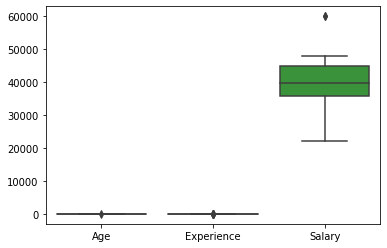

In [51]:
sns.boxplot(data=df_new1)

<AxesSubplot:ylabel='Age'>

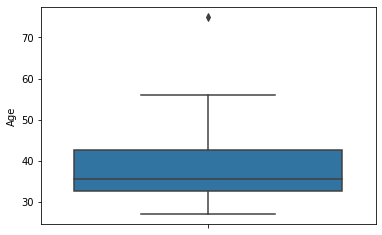

In [50]:
sns.boxplot(y="Age",data=df_new1)

<AxesSubplot:ylabel='Salary'>

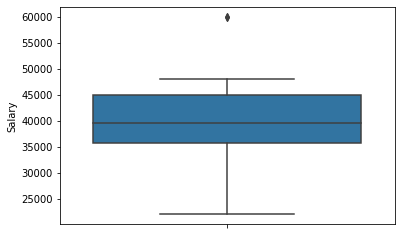

In [52]:
sns.boxplot(y="Salary",data=df_new1)

<AxesSubplot:ylabel='Experience'>

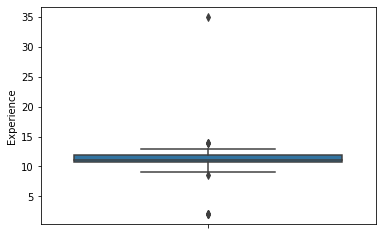

In [53]:
sns.boxplot(y="Experience",data=df_new1)

<AxesSubplot:xlabel='Experience', ylabel='Salary'>

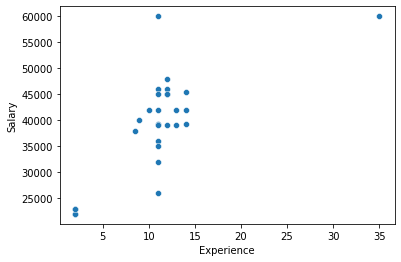

In [54]:
sns.scatterplot(x="Experience",y="Salary",data=df_new1)